In [1]:
from itertools import combinations

import matplotlib.pyplot as plt
import pandas as pd

import scarf
from scarf.plotting import FeatureRef

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_8K_pbmc_citeseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    default_assay="RNA",
    nthreads=4,
)
rna_run = ds.pipeline.open(label="docs_default")
ds

Downloading bucket files: 59899116 / 59899116 complete

Downloading bytes: 59899116 / 59899116 complete

DataStore has 7299 (7865) cells with 2 assays: ADT RNA
   Cell metadata:
            'I', 'ids', 'names', 'ADT_UMAP1', 'ADT_UMAP2', 
            'ADT_leiden_cluster', 'ADT_nCounts', 'ADT_nFeatures', 'RNA+ADT_UMAP1', 'RNA+ADT_UMAP2', 
            'RNA+ADT_leiden_cluster', 'RNA+ADT_wnn_UMAP1', 'RNA+ADT_wnn_UMAP2', 'RNA+ADT_wnn_leiden_cluster', 'RNA_UMAP1', 
            'RNA_UMAP2', 'RNA_clusters', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo'
   ADT assay has 17 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells', 'pattern', 'read', 'sequence'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells', 'pattern', 'read', 'sequence'

In [2]:
[adt_layout] = ds.list_artifacts(
    from_assay="ADT",
    kind="embedding",
    operation="run_umap",
    complete_only=True,
)
[adt_clusters] = ds.list_artifacts(
    from_assay="ADT",
    kind="cluster_labels",
    operation="run_leiden_clustering",
    complete_only=True,
)

{"ADT layout": adt_layout, "ADT clusters": adt_clusters}

{'ADT layout': ArtifactRef(assay='ADT', kind='embedding', artifact_id='02c6d43c8e3c...'),
 'ADT clusters': ArtifactRef(assay='ADT', kind='cluster_labels', artifact_id='d3e6185a3fcd...')}

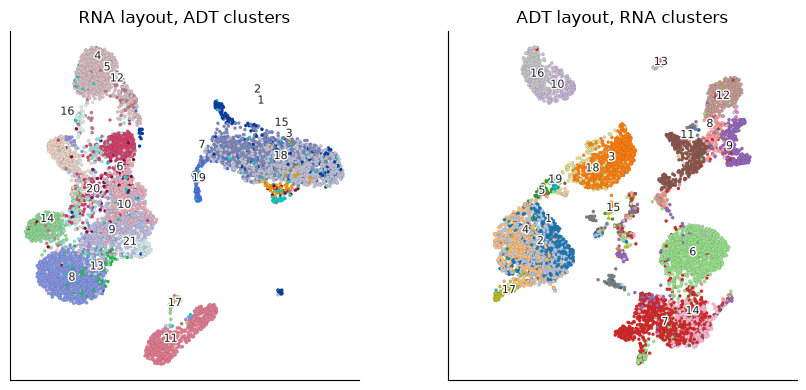

In [3]:
figure, axes = plt.subplots(1, 2, figsize=(9, 4))
for axis, layout, labels, title in (
    (axes[0], rna_run["umap"], adt_clusters, "RNA layout, ADT clusters"),
    (axes[1], adt_layout, rna_run["clusters"], "ADT layout, RNA clusters"),
):
    ds.plots.embedding(
        layout=layout,
        color_by=labels,
        legend_loc="on_data",
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(title)
figure.tight_layout()

In [4]:
[wnn_graph] = ds.list_artifacts(
    scope="datastore",
    kind="integrated_graph",
    operation="integrate_assays",
    parameters={"method": "wnn"},
    complete_only=True,
)
[wnn_layout] = ds.list_artifacts(
    scope="datastore",
    kind="embedding",
    operation="run_umap",
    inputs={"graph": wnn_graph},
    complete_only=True,
)
wnn_layout

ArtifactRef(datastore, kind='embedding', artifact_id='42f1c291488f...')

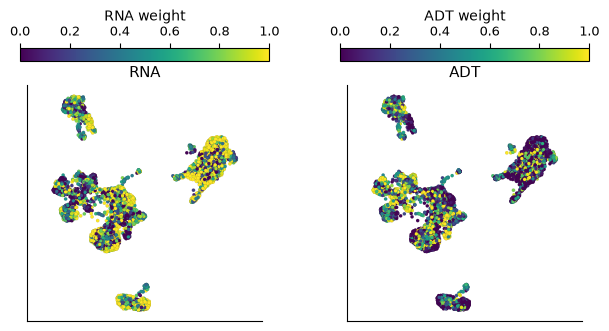

In [5]:
ds.plots.modality_weights(graph=wnn_graph, layout=wnn_layout)

In [6]:
[snn_graph] = ds.list_artifacts(
    scope="datastore",
    kind="integrated_graph",
    operation="integrate_assays",
    parameters={"method": "snn"},
    complete_only=True,
)
[snn_layout] = ds.list_artifacts(
    scope="datastore",
    kind="embedding",
    operation="run_umap",
    inputs={"graph": snn_graph},
    complete_only=True,
)
snn_layout

ArtifactRef(datastore, kind='embedding', artifact_id='abb5eb3ac329...')

In [7]:
[snn_clusters] = ds.list_artifacts(
    scope="datastore",
    kind="cluster_labels",
    operation="run_leiden_clustering",
    inputs={"graph": snn_graph},
    complete_only=True,
)
[wnn_clusters] = ds.list_artifacts(
    scope="datastore",
    kind="cluster_labels",
    operation="run_leiden_clustering",
    inputs={"graph": wnn_graph},
    complete_only=True,
)
{"SNN clusters": snn_clusters, "WNN clusters": wnn_clusters}

{'SNN clusters': ArtifactRef(datastore, kind='cluster_labels', artifact_id='3d171670dbdf...'),
 'WNN clusters': ArtifactRef(datastore, kind='cluster_labels', artifact_id='0089d0127c5f...')}

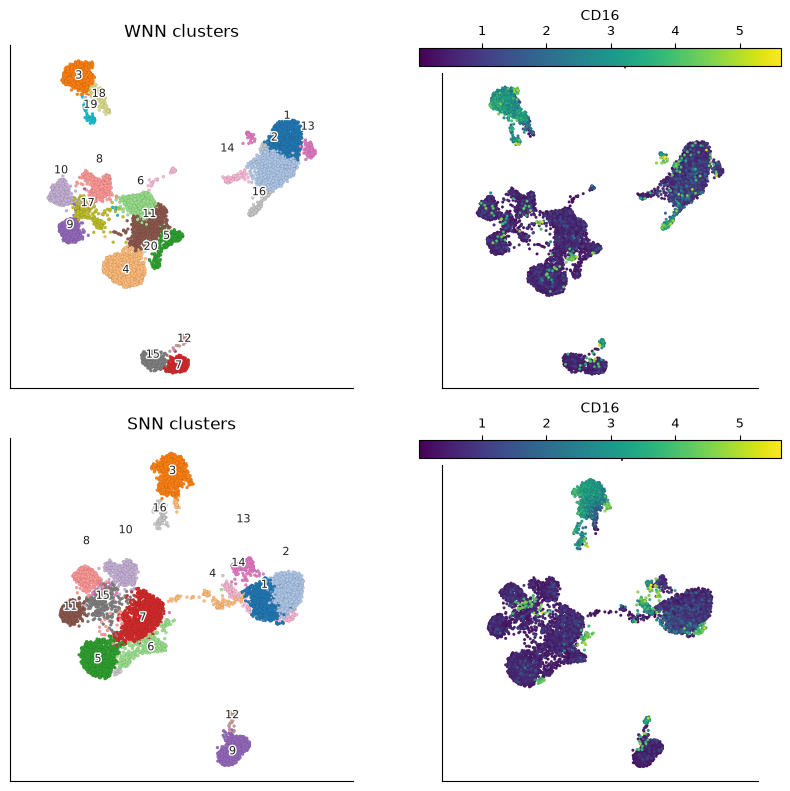

In [8]:
cd16 = FeatureRef("CD16", assay="ADT", by="id", label="CD16")
figure, axes = plt.subplots(2, 2, figsize=(9, 8))
for row, layout, labels, method in (
    (0, wnn_layout, wnn_clusters, "WNN"),
    (1, snn_layout, snn_clusters, "SNN"),
):
    ds.plots.embedding(
        layout=layout,
        color_by=labels,
        legend_loc="on_data",
        show_titles=False,
        target=axes[row, 0],
        show=False,
    )
    axes[row, 0].set_title(f"{method} clusters")
    ds.plots.embedding(
        layout=layout,
        color_by=cd16,
        sort_values=True,
        show_titles=False,
        target=axes[row, 1],
        show=False,
    )
    axes[row, 1].set_title(f"{method}: CD16 protein")
figure.tight_layout()

In [9]:
partitions = {
    "RNA": rna_run["clusters"],
    "ADT": adt_clusters,
    "SNN": snn_clusters,
    "WNN": wnn_clusters,
}
concordance = []
for first, second in combinations(partitions, 2):
    ari = ds.metric_label_concordance(partitions[first], partitions[second], metric="ari")
    nmi = ds.metric_label_concordance(partitions[first], partitions[second], metric="nmi")
    concordance.append({"comparison": f"{first} vs {second}", "ARI": ari, "NMI": nmi})
pd.DataFrame(concordance)

,comparison,ARI,NMI
0,RNA vs ADT,0.576373,0.671074
1,RNA vs SNN,0.676909,0.779611
2,RNA vs WNN,0.739431,0.824727
3,ADT vs SNN,0.713908,0.782535
4,ADT vs WNN,0.655779,0.744723
5,SNN vs WNN,0.749559,0.842040
